# EDA inicial - Requerimientos (No supervisado)

Objetivo: explorar calidad y estructura de datos para preparar un modelo no supervisado usando únicamente short_description y description.
Variables de fuga como assignment_group y assigned_to no se usarán para modelado.

In [328]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
from pathlib import Path

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [329]:
# 1) Carga robusta del CSV objetivo (funciona desde raíz o desde Data)
from pathlib import Path
import pandas as pd

nombre_csv = "requerimientos_2026-05-28_17-09-55.csv"
cwd = Path.cwd()

candidatas = [
    cwd / nombre_csv,                    # si el notebook corre desde Data
    cwd / "Data" / nombre_csv,           # si corre desde la raíz del proyecto
    cwd.parent / "Data" / nombre_csv,    # si corre desde una subcarpeta (ej. Analisis/)
]

ruta_csv = next((p for p in candidatas if p.exists()), None)

if ruta_csv is None:
    buscados = "\n".join(str(p.resolve()) for p in candidatas)
    raise FileNotFoundError(f"No existe el archivo en ninguna ruta candidata:\n{buscados}")

print("Archivo seleccionado:", ruta_csv.resolve())

df = pd.read_csv(
    ruta_csv,
    sep=";",
    encoding="latin-1",
    dtype=str,
    engine="python",
    on_bad_lines="skip"
)

print("Dimensiones:", df.shape)
display(df.head(3))
print("\nColumnas:")
print(df.columns.tolist())

Archivo seleccionado: C:\ASIGNADOR\Asignador\Data\requerimientos_2026-05-28_17-09-55.csv
Dimensiones: (11216, 13)


,number,state,ref_sc_req_item.requested_for,requested_for.vip,requested_for.email,requested_for.title,requested_for.company,assigned_to,assignment_group,short_description,cat_item.sc_catalogs,description,u_variables_texto
0,RITM0716416,Cerrado,ANGELA MERCEDES OBANDO BERNAL,falso,amobando@pichincha.com,EJECUTIVO BACK Y SERVICIOS,Banco Pichincha C.A.,KONERI DAMODARAM,TEC_TCS_BANCS,Requerimientos de información relacionados a B...,TI,Estimados su gentil ayuda con el cambio de es...,NaN
1,RITM0620071,Cerrado,JHOSUE DAVID BRITO ASTUDILLO,falso,jbritoas@pichincha.com,SOPORTE ADMINISTRATIVO,Banco Pichincha C.A.,MARCELA YADIRA ZUNIGA UBILLUZ,TEC_TCS_BANCS,Requerimientos de información relacionados a B...,TI,¿Cómo se genera la información del archivo de ...,NaN
2,RITM0754745,Cerrado,XIOMARA ELIZABETH CEVALLOS TENORIO,falso,xecevall@pichincha.com,EJECUTIVO COMERCIAL RELACIONAL,Banco Pichincha C.A.,LEONELA JACKELINE DELGADO MENDIETA,TEC_TCS_BANCS,Requerimientos de información relacionados a B...,TI,¿Buenos días por favor su ayuda con revisión a...,NaN



Columnas:
['number', 'state', 'ref_sc_req_item.requested_for', 'requested_for.vip', 'requested_for.email', 'requested_for.title', 'requested_for.company', 'assigned_to', 'assignment_group', 'short_description', 'cat_item.sc_catalogs', 'description', 'u_variables_texto']


In [330]:
# 2) Definir columnas para modelado no supervisado
cols_texto = ["short_description", "description"]
faltantes = [c for c in cols_texto if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas críticas: {faltantes}")

# Solo dejamos columnas útiles para esta fase
cols_base = [c for c in ["number", "state"] if c in df.columns] + cols_texto
df_eda = df[cols_base].copy()

print("Columnas en df_eda:", df_eda.columns.tolist())
print("Registros:", len(df_eda))
display(df_eda.head(3))

Columnas en df_eda: ['number', 'state', 'short_description', 'description']
Registros: 11216


,number,state,short_description,description
0,RITM0716416,Cerrado,Requerimientos de información relacionados a B...,Estimados su gentil ayuda con el cambio de es...
1,RITM0620071,Cerrado,Requerimientos de información relacionados a B...,¿Cómo se genera la información del archivo de ...
2,RITM0754745,Cerrado,Requerimientos de información relacionados a B...,¿Buenos días por favor su ayuda con revisión a...


In [331]:
# 3) Calidad de datos de texto: nulos, vacíos, cardinalidad

def es_vacio(x):
    if pd.isna(x):
        return True
    s = str(x).strip().lower()
    return s in {"", "nan", "none", "null"}

resumen_calidad = []
for c in cols_texto:
    vacios = df_eda[c].apply(es_vacio).sum()
    resumen_calidad.append({
        "columna": c,
        "n_registros": len(df_eda),
        "n_vacios": int(vacios),
        "pct_vacios": round(vacios / len(df_eda) * 100, 2),
        "n_unicos_no_nulos": int(df_eda[c].nunique(dropna=True))
    })

resumen_calidad = pd.DataFrame(resumen_calidad)
display(resumen_calidad)

,columna,n_registros,n_vacios,pct_vacios,n_unicos_no_nulos
0,short_description,11216,0,0.0,32
1,description,11216,1323,11.8,9264


In [332]:
# 4) Construir texto unificado SOLO con short_description + description
df_eda["texto_unificado_raw"] = (
    df_eda["short_description"].fillna("").astype(str).str.strip() + " " +
    df_eda["description"].fillna("").astype(str).str.strip()
).str.replace(r"\s+", " ", regex=True).str.strip()

df_eda["texto_vacio"] = df_eda["texto_unificado_raw"].eq("")

print("Registros sin texto útil:", int(df_eda["texto_vacio"].sum()))
print("Porcentaje sin texto útil:", round(df_eda["texto_vacio"].mean() * 100, 2), "%")
display(df_eda[["texto_unificado_raw", "texto_vacio"]].head(5))

Registros sin texto útil: 0
Porcentaje sin texto útil: 0.0 %


,texto_unificado_raw,texto_vacio
0,Requerimientos de información relacionados a B...,False
1,Requerimientos de información relacionados a B...,False
2,Requerimientos de información relacionados a B...,False
3,Requerimientos de información relacionados a B...,False
4,Requerimientos de información relacionados a B...,False


In [333]:
# 5) Duplicados exactos (muy importante para clustering)
dup_pair = df_eda[cols_texto].fillna("").duplicated(keep=False)
dup_texto = df_eda["texto_unificado_raw"].duplicated(keep=False)

print("Duplicados por (short_description, description):", int(dup_pair.sum()))
print("Duplicados por texto_unificado_raw:", int(dup_texto.sum()))

# Muestra de ejemplos duplicados
ej_dup = df_eda.loc[dup_texto, ["number", "short_description", "description", "texto_unificado_raw"]].head(10)
display(ej_dup)

Duplicados por (short_description, description): 2244
Duplicados por texto_unificado_raw: 2289


,number,short_description,description,texto_unificado_raw
6,RITM0658358,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...
7,RITM0594481,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...
8,RITM0625900,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...
36,RITM0725104,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
37,RITM0718982,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
63,RITM0698508,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
64,RITM0698553,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
71,RITM0698520,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
72,RITM0698567,Requerimientos de información relacionados a B...,Ver movimientos de BANCS para el incidente INC...,Requerimientos de información relacionados a B...
167,RITM0826292,Requerimientos de información relacionados a B...,Test: Por favor su ayuda para la obtención de ...,Requerimientos de información relacionados a B...


          len_chars     len_words
count  11216.000000  11216.000000
mean     287.924572     43.879101
std      237.605444     32.774219
min       13.000000      2.000000
25%      178.000000     27.000000
50%      257.000000     39.000000
75%      343.000000     55.000000
90%      482.000000     75.000000
95%      592.000000     91.000000
99%     1031.700000    148.850000
max    12446.000000   1224.000000


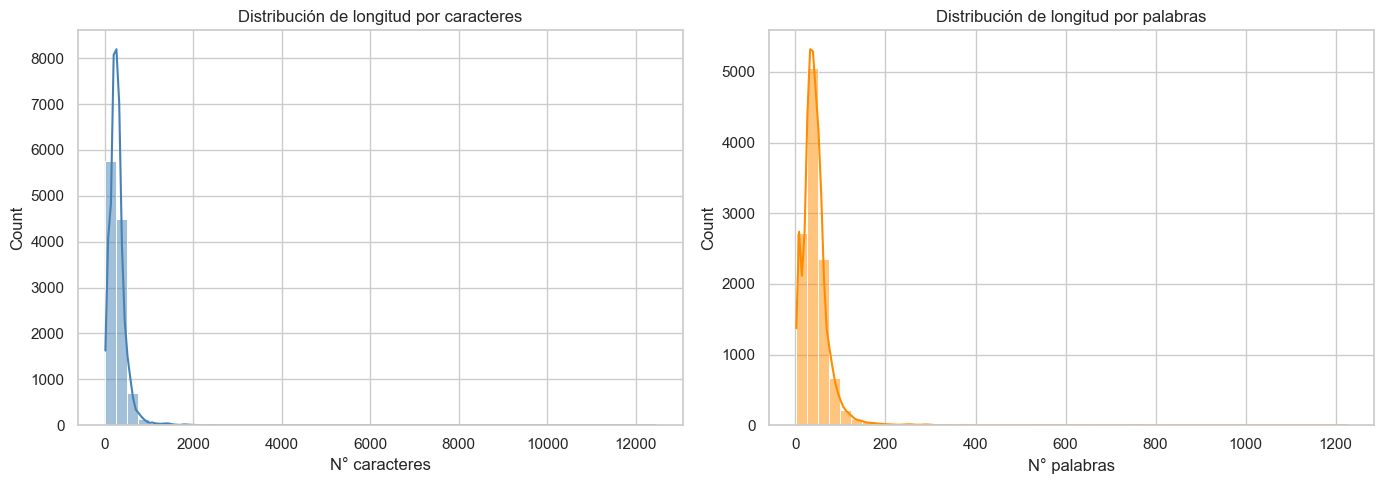

In [334]:
# 6) Longitud del texto: chars y palabras
df_len = df_eda.loc[~df_eda["texto_vacio"]].copy()
df_len["len_chars"] = df_len["texto_unificado_raw"].str.len()
df_len["len_words"] = df_len["texto_unificado_raw"].str.split().str.len()

print(df_len[["len_chars", "len_words"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_len["len_chars"], bins=50, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Distribución de longitud por caracteres")
ax[0].set_xlabel("N° caracteres")

sns.histplot(df_len["len_words"], bins=50, kde=True, ax=ax[1], color="darkorange")
ax[1].set_title("Distribución de longitud por palabras")
ax[1].set_xlabel("N° palabras")

plt.tight_layout()
plt.show()

In [335]:
# 7) Señal de "plantillas" repetitivas en short_description
top_short = (
    df_eda["short_description"]
    .fillna("VACIO")
    .astype(str)
    .str.strip()
    .value_counts()
    .head(15)
)

print("Top 15 short_description más frecuentes:")
display(top_short.to_frame("frecuencia"))

Top 15 short_description más frecuentes:


,frecuencia
short_description,
Requerimientos de información relacionados a Bancs y BancsLink,10723
Atención solicitudes Bancs y BancsLinks,399
Procesos Batch,20
Requerimientos de Información Mantenimiento,13
Requerimientos para facturación estados de cuenta,11
SISREP - Requerimientos de información relacionados a Bancs y BancsLink,8
"Creación, modificación, eliminación de perfiles globales y gestión de accesos a nivel de perfil global o transaccional de aplicaciones",5
Requerimiento Iniciativas Cambios,5
Requerimientos Cash,3


# Limpieza inicial - Requerimientos (No supervisado)

Objetivo: limpieza de datos previa al modelado

In [336]:
# 8) Separar dataset de modelado (solo texto) y dataset de auditoría
# number se conserva SOLO para trazabilidad, no para features
df_model = df_eda[["number", "short_description", "description"]].copy()

print("Registros base:", len(df_model))
display(df_model.head(3))

Registros base: 11216


,number,short_description,description
0,RITM0716416,Requerimientos de información relacionados a B...,Estimados su gentil ayuda con el cambio de es...
1,RITM0620071,Requerimientos de información relacionados a B...,¿Cómo se genera la información del archivo de ...
2,RITM0754745,Requerimientos de información relacionados a B...,¿Buenos días por favor su ayuda con revisión a...


In [337]:
# 8b) Instalar y cargar spaCy (ejecutar solo la primera vez)
import spacy
nlp_es = spacy.load("es_core_news_md", disable=["ner", "parser", "senter"])
print("spaCy listo:", nlp_es.meta["name"], "| Pipeline:", nlp_es.pipe_names)

spaCy listo: core_news_md | Pipeline: ['tok2vec', 'morphologizer', 'attribute_ruler', 'lemmatizer']


In [338]:
# 9) Limpieza textual robusta + lemmatización spaCy para clustering
import re
import unicodedata

_PLACEHOLDERS = {"url", "email", "fecha", "num_largo", "num"}

def normalize_text(texto):
    if pd.isna(texto):
        return ""

    t = str(texto).strip().lower()

    # 1) NFKC: normaliza unicode CONSERVANDO acentos (spaCy los necesita)
    t = unicodedata.normalize("NFKC", t)

    # 2) Enmascarar patrones ruidosos (antes de lemmatizar)
    t = re.sub(r"(https?://\S+|www\.\S+)", " url ", t)
    t = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " email ", t)
    t = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", " fecha ", t)
    t = re.sub(r"\b\d{7,}\b", " num_largo ", t)
    t = re.sub(r"\b\d+\b", " num ", t)

    # 3) Quitar puntuación, pero CONSERVAR letras acentuadas
    t = re.sub(r"[_\-=/\\\|\(\)\[\]\{\},;:]+", " ", t)
    t = re.sub(r"[^\w\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    # 4) Lemmatizar con spaCy (cheques→cheque, incidencias→incidencia, etc.)
    doc = nlp_es(t)
    lemmas = []
    for token in doc:
        if token.is_space:
            continue
        raw = token.lower_.strip()
        if raw in _PLACEHOLDERS:
            lemmas.append(raw)          # no lemmatizar placeholders
        else:
            lemma = token.lemma_.lower().strip()
            if lemma:
                lemmas.append(lemma)
    t = " ".join(lemmas)

    # 5) Ahora sí: quitar acentos → ASCII puro
    t = unicodedata.normalize("NFKD", t)
    t = t.encode("ascii", "ignore").decode("utf-8", errors="ignore")

    # 6) Solo letras y números
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    return t

In [339]:
# 10) Limpiar columnas textuales
df_model["short_clean"] = df_model["short_description"].apply(normalize_text)
df_model["desc_clean"] = df_model["description"].apply(normalize_text)

# short_description suele ser plantilla; description lleva mas señal
# Damos mayor peso a description repitiendola una vez adicional
df_model["texto_limpio"] = (
    df_model["short_clean"] + " " +
    df_model["desc_clean"] + " " +
    df_model["desc_clean"]
).str.replace(r"\s+", " ", regex=True).str.strip()

display(df_model[["short_description", "description", "texto_limpio"]].head(3))

,short_description,description,texto_limpio
0,Requerimientos de información relacionados a B...,Estimados su gentil ayuda con el cambio de es...,requerimiento de informacion relacionado a ban...
1,Requerimientos de información relacionados a B...,¿Cómo se genera la información del archivo de ...,requerimiento de informacion relacionado a ban...
2,Requerimientos de información relacionados a B...,¿Buenos días por favor su ayuda con revisión a...,requerimiento de informacion relacionado a ban...


In [340]:
# Validación de limpieza
muestra_validacion = df_model[[
    "number", "short_description", "description", "short_clean", "desc_clean", "texto_limpio"
]].head(10).copy()

display(muestra_validacion)

print("Conteo de placeholders en texto_limpio:")
print("fecha:", int(df_model["texto_limpio"].str.contains(r"\bfecha\b", regex=True).sum()))
print("num_largo:", int(df_model["texto_limpio"].str.contains(r"\bnum_largo\b", regex=True).sum()))
print("num:", int(df_model["texto_limpio"].str.contains(r"\bnum\b", regex=True).sum()))
print("email:", int(df_model["texto_limpio"].str.contains(r"\bemail\b", regex=True).sum()))
print("url:", int(df_model["texto_limpio"].str.contains(r"\burl\b", regex=True).sum()))

print("\nConteo de caracteres raros remanentes:")
print(" :", int(df_model["texto_limpio"].str.contains("", regex=False).sum()))
print("� :", int(df_model["texto_limpio"].str.contains("�", regex=False).sum()))
print("¿ :", int(df_model["texto_limpio"].str.contains("¿", regex=False).sum()))
print("¡ :", int(df_model["texto_limpio"].str.contains("¡", regex=False).sum()))

,number,short_description,description,short_clean,desc_clean,texto_limpio
0,RITM0716416,Requerimientos de información relacionados a B...,Estimados su gentil ayuda con el cambio de es...,requerimiento de informacion relacionado a ban...,estimado su gentil ayuda con el cambio de esta...,requerimiento de informacion relacionado a ban...
1,RITM0620071,Requerimientos de información relacionados a B...,¿Cómo se genera la información del archivo de ...,requerimiento de informacion relacionado a ban...,como el generar el informacion del archivo de ...,requerimiento de informacion relacionado a ban...
2,RITM0754745,Requerimientos de información relacionados a B...,¿Buenos días por favor su ayuda con revisión a...,requerimiento de informacion relacionado a ban...,buen dia por favor su ayuda con revision a que...,requerimiento de informacion relacionado a ban...
3,RITM0795775,Requerimientos de información relacionados a B...,]Estimado su gentil apoyo con el pedido del cl...,requerimiento de informacion relacionado a ban...,estimado su gentil apoyo con el pedido del cli...,requerimiento de informacion relacionado a ban...
4,RITM0424331,Requerimientos de información relacionados a B...,[Iniciativa Multi Core] - Configuración de Cup...,requerimiento de informacion relacionado a ban...,iniciativa multi core configuracion de cupo so...,requerimiento de informacion relacionado a ban...
5,RITM0709362,Requerimientos de información relacionados a B...,Versionar el shell camRepCanjeEnf1.sh.,requerimiento de informacion relacionado a ban...,versionar el shell camrepcanjeenf1 sh,requerimiento de informacion relacionado a ban...
6,RITM0658358,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,requerimiento de informacion relacionado a ban...,versionar el proceso dev check sh y posterior ...,requerimiento de informacion relacionado a ban...
7,RITM0594481,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,requerimiento de informacion relacionado a ban...,versionar el proceso dev check sh y posterior ...,requerimiento de informacion relacionado a ban...
8,RITM0625900,Requerimientos de información relacionados a B...,Versionar el proceso dev_check.sh y posterior ...,requerimiento de informacion relacionado a ban...,versionar el proceso dev check sh y posterior ...,requerimiento de informacion relacionado a ban...
9,RITM0741342,Requerimientos de información relacionados a B...,Ver movimientos de BANCS por petición de MONTE...,requerimiento de informacion relacionado a ban...,ver movimiento de bancs por peticion de monten...,requerimiento de informacion relacionado a ban...


Conteo de placeholders en texto_limpio:


fecha: 2585
num_largo: 0
num: 7755
email: 99
url: 90

Conteo de caracteres raros remanentes:
 : 0
� : 0
¿ : 0
¡ : 0


In [341]:
# 11) Filtrar textos no informativos
df_model["n_tokens"] = df_model["texto_limpio"].str.split().str.len()

# Regla base: al menos 4 tokens utiles
df_model["valido_modelo"] = df_model["n_tokens"] >= 4

print("Registros validos para modelo:", int(df_model["valido_modelo"].sum()))
print("Registros descartados por poco texto:", int((~df_model["valido_modelo"]).sum()))

display(df_model.loc[~df_model["valido_modelo"], ["number", "texto_limpio", "n_tokens"]].head(10))

Registros validos para modelo: 11203
Registros descartados por poco texto: 13


,number,texto_limpio,n_tokens
10003,RITM0804446,acceso cyberark,2
10022,RITM0110936,proceso batch,2
10080,RITM0112488,proceso batch,2
10137,RITM0300491,proceso batch,2
10446,RITM0390620,requerimiento iniciativa cambio,3
10467,RITM0327879,requerimiento iniciativa cambio,3
10621,RITM0266502,soporte red,2
10660,RITM0111247,proceso batch,2
10714,RITM0059903,proceso batch,2
10942,RITM0197186,proceso batch,2


In [342]:
# 12) Crear dataset de entrenamiento para clustering
df_fit_full = df_model.loc[df_model["valido_modelo"], ["number", "texto_limpio"]].copy()

# Deduplicado exacto SOLO para ajustar modelo sin sesgo por repeticion
df_fit_unique = (
    df_fit_full
    .drop_duplicates(subset=["texto_limpio"])
    .reset_index(drop=True)
)

print("Registros para fit (con repetidos):", len(df_fit_full))
print("Registros para fit (texto unico):", len(df_fit_unique))
print("Reduccion:", round((1 - len(df_fit_unique) / len(df_fit_full)) * 100, 2), "%")

Registros para fit (con repetidos): 11203
Registros para fit (texto unico): 8362
Reduccion: 25.36 %


In [343]:
# 13) Frecuencia de textos (importante para analisis operativo)
freq_texto = (
    df_fit_full
    .groupby("texto_limpio", as_index=False)
    .agg(
        frecuencia=("number", "count"),
        ejemplos_number=("number", lambda x: ", ".join(x.head(5)))
    )
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(freq_texto.head(15))

,texto_limpio,frecuencia,ejemplos_number
0,requerimiento de informacion relacionado a ban...,1214,"RITM0549138, RITM0293805, RITM0454559, RITM036..."
1,requerimiento de informacion relacionado a ban...,226,"RITM0527477, RITM0753925, RITM0516740, RITM086..."
2,atencion solicitud bancs y bancslinks,94,"RITM0061258, RITM0058580, RITM0086319, RITM008..."
3,requerimiento de informacion relacionado a ban...,68,"RITM0688742, RITM0686756, RITM0722457, RITM088..."
4,requerimiento de informacion relacionado a ban...,46,"RITM0745463, RITM0737022, RITM0731743, RITM071..."
5,requerimiento de informacion relacionado a ban...,45,"RITM0363677, RITM0831353, RITM0585399, RITM058..."
6,requerimiento de informacion relacionado a ban...,26,"RITM0795321, RITM0754302, RITM0789271, RITM072..."
7,requerimiento de informacion relacionado a ban...,19,"RITM0851336, RITM0816260, RITM0783757, RITM072..."
8,requerimiento de informacion relacionado a ban...,17,"RITM0569512, RITM0571823, RITM0567938, RITM056..."
9,requerimiento de informacion relacionado a ban...,15,"RITM0465337, RITM0465343, RITM0465361, RITM046..."


In [344]:
# 14) Objetos que usaremos en clustering
# - df_fit_unique["texto_limpio"] -> entrenamiento del clustering
# - df_fit_full -> para asignar cluster a todos los tickets validos
# - df_model -> para trazabilidad completa por number
print("Listo para clustering no supervisado.")
print("Variables clave: df_fit_unique, df_fit_full, df_model, freq_texto")

Listo para clustering no supervisado.
Variables clave: df_fit_unique, df_fit_full, df_model, freq_texto


In [345]:
# 15) Remover boilerplate de negocio (v5 robusto)

boilerplate_patterns = [
    # Encabezados tipicos de short_description
    r"\brequerimientos?\s+de\s+informacion\s+relacionados?\s+a\s+bancs?\s+y\s+bancslinks?\b",
    r"\batencion\s+solicitudes?\s+bancs?\s+y\s+bancslinks?\b",
    r"\bestimad[oa]s?\b",
    r"\bbuen[oa]s?\s+d[ii]as?\b",
    r"\bbuen[oa]s?\s+tardes?\b",
    r"\bbuen[oa]s?\s+noches?\b",
    r"\bbuen\s+d[ii]a\b",   # forma corta sin s

    # Saludos y apertura
    r"^\s*estimad[oa]s?\b",
    r"^\s*buen[oa]s?\s+d[ii]as\b",
    r"^\s*buen[oa]s?\s+tardes\b",
    r"^\s*buen[oa]s?\s+noches\b",


    r"\bespero\s+se\s+encuentren\s+bien\b",

    # Frases blandas frecuentes
    r"\bpor\s+favor\b",
    r"\bfavor\b",
    r"\bfavor\s+con\b",
    r"\bsu\s+gentil\s+ayuda\b",
    r"\bsu\s+ayuda\b",
    r"\bsu\s+gentil\s+apoyo\b",
    r"\bsu\s+apoyo\b",
    r"\bgentil\s+apoyo\b",
    r"\bfavor\s+su\s+ayuda\b",
    r"\bpor\s+favor\s+su\s+ayuda\s+con\b",
    r"\bpor\s+favor\s+su\s+apoyo\s+con\b",
    r"\bpor\s+favor\s+apoyar\b",
    r"\bpor\s+favor\s+ayudar\b",
    r"\bsu\s+gentil\s+apoyo\s+con\b",
    r"\bsu\s+ayuda\s+con\b",
    r"\bapoyo\s+con\b",
    r"\bayuda\s+con\b",

    # Cierre y cortesia
    r"\batenta?\s+a\s+sus\s+comentarios\b",
    r"\bquedo\s+atent[oa]\b",
    r"\bde\s+antemano\b",
    r"\bles\s+agradezco\b",
    r"\bagradezco\s+su\s+ayuda\b",
    r"\bcordial(?:es)?\s+saludos\b",
    r"\bsaludos?\s+cordiales?\b",
    r"\bsaludos?\b",
    r"\bgracias\b",
    r"\badjunto\b",

    # ANTES → DESPUÉS (forma lema que spaCy produce)
    r"\besperar\s+se\s+encontrar\s+bien\b",     
    r"\badjuntar\b",                               
    r"\bquedar\s+atent[oa]\b",                   
    r"\bcordial(?:es)?\s+saludo[s]?\b",           
    r"\bgracia[s]?\b",                           
    r"\ble[s]?\s+agradecer\b",                    
    r"\bagradecer\s+su\s+ayuda\b",               
    r"\batento?\s+a\s+su[s]?\s+comentario[s]?\b", 
]

boilerplate_regex = re.compile("|".join(boilerplate_patterns))
prefix_regex = re.compile(r"^(con|con el|con la|con los|con las|para|sobre|del|de la|de los|de las)\s+")

def strip_boilerplate(texto):
    if pd.isna(texto):
        return ""
    t = str(texto)

    # 1) quitar boilerplate en varias pasadas
    for _ in range(6):
        t_new = boilerplate_regex.sub(" ", t)
        t_new = re.sub(r"\s+", " ", t_new).strip()
        if t_new == t:
            break
        t = t_new

    # 2) quitar conectores residuales al inicio
    for _ in range(4):
        t_new = prefix_regex.sub("", t).strip()
        if t_new == t:
            break
        t = t_new

    # 3) limpieza final
    t = re.sub(r"\s+", " ", t).strip()
    return t

df_model["short_core"] = df_model["short_clean"].apply(strip_boilerplate)
df_model["desc_core"] = df_model["desc_clean"].apply(strip_boilerplate)

display(df_model[["short_clean", "short_core", "desc_clean", "desc_core"]].head(10))

,short_clean,short_core,desc_clean,desc_core
0,requerimiento de informacion relacionado a ban...,,estimado su gentil ayuda con el cambio de esta...,el cambio de estado chequera cta cte num largo...
1,requerimiento de informacion relacionado a ban...,,como el generar el informacion del archivo de ...,como el generar el informacion del archivo de ...
2,requerimiento de informacion relacionado a ban...,,buen dia por favor su ayuda con revision a que...,revision a que corresponder este valor cliente...
3,requerimiento de informacion relacionado a ban...,,estimado su gentil apoyo con el pedido del cli...,el pedido del cliente pintura color num s a s ...
4,requerimiento de informacion relacionado a ban...,,iniciativa multi core configuracion de cupo so...,iniciativa multi core configuracion de cupo so...
5,requerimiento de informacion relacionado a ban...,,versionar el shell camrepcanjeenf1 sh,versionar el shell camrepcanjeenf1 sh
6,requerimiento de informacion relacionado a ban...,,versionar el proceso dev check sh y posterior ...,versionar el proceso dev check sh y posterior ...
7,requerimiento de informacion relacionado a ban...,,versionar el proceso dev check sh y posterior ...,versionar el proceso dev check sh y posterior ...
8,requerimiento de informacion relacionado a ban...,,versionar el proceso dev check sh y posterior ...,versionar el proceso dev check sh y posterior ...
9,requerimiento de informacion relacionado a ban...,,ver movimiento de bancs por peticion de monten...,ver movimiento de bancs por peticion de monten...


In [346]:
# 16) Construir texto final priorizando description (v3)
def es_texto_informativo(txt, min_tokens=4):
    if pd.isna(txt):
        return False
    t = str(txt).strip()
    if t == "":
        return False
    return len(t.split()) >= min_tokens

def construir_texto_final(row):
    d = row["desc_core"] if pd.notna(row["desc_core"]) else ""
    s = row["short_core"] if pd.notna(row["short_core"]) else ""

    d_ok = es_texto_informativo(d, min_tokens=4)
    s_ok = es_texto_informativo(s, min_tokens=4)

    if d_ok and s_ok:
        return (d + " " + s).strip(), "desc_core+short_core"
    if d_ok:
        return d.strip(), "desc_core"
    if s_ok:
        return s.strip(), "short_core"

    # Si ninguno es informativo, no reinyectar short_clean genérico automáticamente
    return "", "none"

tmp = df_model.apply(construir_texto_final, axis=1)
df_model["texto_limpio_v2"] = tmp.apply(lambda x: x[0])
df_model["source_text_v2"] = tmp.apply(lambda x: x[1])

display(df_model[["description", "short_description", "desc_core", "short_core", "texto_limpio_v2", "source_text_v2"]].head(10))
print(df_model["source_text_v2"].value_counts(dropna=False))

,description,short_description,desc_core,short_core,texto_limpio_v2,source_text_v2
0,Estimados su gentil ayuda con el cambio de es...,Requerimientos de información relacionados a B...,el cambio de estado chequera cta cte num largo...,,el cambio de estado chequera cta cte num largo...,desc_core
1,¿Cómo se genera la información del archivo de ...,Requerimientos de información relacionados a B...,como el generar el informacion del archivo de ...,,como el generar el informacion del archivo de ...,desc_core
2,¿Buenos días por favor su ayuda con revisión a...,Requerimientos de información relacionados a B...,revision a que corresponder este valor cliente...,,revision a que corresponder este valor cliente...,desc_core
3,]Estimado su gentil apoyo con el pedido del cl...,Requerimientos de información relacionados a B...,el pedido del cliente pintura color num s a s ...,,el pedido del cliente pintura color num s a s ...,desc_core
4,[Iniciativa Multi Core] - Configuración de Cup...,Requerimientos de información relacionados a B...,iniciativa multi core configuracion de cupo so...,,iniciativa multi core configuracion de cupo so...,desc_core
5,Versionar el shell camRepCanjeEnf1.sh.,Requerimientos de información relacionados a B...,versionar el shell camrepcanjeenf1 sh,,versionar el shell camrepcanjeenf1 sh,desc_core
6,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...,versionar el proceso dev check sh y posterior ...,,versionar el proceso dev check sh y posterior ...,desc_core
7,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...,versionar el proceso dev check sh y posterior ...,,versionar el proceso dev check sh y posterior ...,desc_core
8,Versionar el proceso dev_check.sh y posterior ...,Requerimientos de información relacionados a B...,versionar el proceso dev check sh y posterior ...,,versionar el proceso dev check sh y posterior ...,desc_core
9,Ver movimientos de BANCS por petición de MONTE...,Requerimientos de información relacionados a B...,ver movimiento de bancs por peticion de monten...,,ver movimiento de bancs por peticion de monten...,desc_core


source_text_v2
desc_core               9521
none                    1251
desc_core+short_core     346
short_core                98
Name: count, dtype: int64


In [347]:
# 17) Recalcular filtro de textos informativos con v2
df_model["n_tokens_v2"] = df_model["texto_limpio_v2"].str.split().str.len().fillna(0).astype(int)
df_model["valido_modelo_v2"] = df_model["n_tokens_v2"] >= 4

print("Validos v2:", int(df_model["valido_modelo_v2"].sum()))
print("Descartados v2:", int((~df_model["valido_modelo_v2"]).sum()))

print("\nDescarte por fuente:")
display(df_model.loc[~df_model["valido_modelo_v2"], "source_text_v2"].value_counts(dropna=False).to_frame("conteo"))

display(df_model.loc[~df_model["valido_modelo_v2"], ["number", "source_text_v2", "texto_limpio_v2", "n_tokens_v2"]].head(10))

Validos v2: 9965
Descartados v2: 1251

Descarte por fuente:


,conteo
source_text_v2,
none,1251


,number,source_text_v2,texto_limpio_v2,n_tokens_v2
191,RITM0542626,none,,0
633,RITM0353693,none,,0
1989,RITM0394170,none,,0
2052,RITM0618044,none,,0
2728,RITM0905678,none,,0
2729,RITM0679373,none,,0
3652,RITM0730451,none,,0
3691,RITM0821120,none,,0
4627,RITM0370719,none,,0
5644,RITM0860995,none,,0


In [348]:
# 18) Recalcular fit y deduplicación con v2
df_fit_full_v2 = df_model.loc[df_model["valido_modelo_v2"], ["number", "texto_limpio_v2", "source_text_v2"]].copy()

df_fit_unique_v2 = (
    df_fit_full_v2
    .drop_duplicates(subset=["texto_limpio_v2"])
    .reset_index(drop=True)
)

print("Fit v2 (con repetidos):", len(df_fit_full_v2))
print("Fit v2 (texto unico):", len(df_fit_unique_v2))
print("Reduccion v2:", round((1 - len(df_fit_unique_v2) / len(df_fit_full_v2)) * 100, 2), "%")

Fit v2 (con repetidos): 9965
Fit v2 (texto unico): 8301
Reduccion v2: 16.7 %


In [349]:
# 19) Frecuencias top con v2
freq_texto_v2 = (
    df_fit_full_v2
    .groupby("texto_limpio_v2", as_index=False)
    .agg(
        frecuencia=("number", "count"),
        ejemplos_number=("number", lambda x: ", ".join(x.head(5))),
        fuente_predominante=("source_text_v2", lambda x: x.value_counts().index[0] if len(x) else "NA")
    )
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(freq_texto_v2.head(15))

,texto_limpio_v2,frecuencia,ejemplos_number,fuente_predominante
0,el cambio de estado de pagado a activo del che...,229,"RITM0499870, RITM0362294, RITM0527477, RITM075...",desc_core
1,atencion solicitud bancs y bancslinks,96,"RITM0073151, RITM0064136, RITM0061258, RITM005...",short_core
2,motor de transferencia con el informacion de e...,68,"RITM0688742, RITM0686756, RITM0722457, RITM088...",desc_core
3,el obtencion de el glif del archivo,50,"RITM0363677, RITM0831353, RITM0585399, RITM058...",desc_core
4,esperar el encontrar bien solicitar su amable ...,46,"RITM0745463, RITM0737022, RITM0731743, RITM071...",desc_core
5,el cambio de estado a deteriorado el forma num...,26,"RITM0795321, RITM0754302, RITM0789271, RITM072...",desc_core
6,bancs test con el reinicio de el puerto num y ...,22,"RITM0242686, RITM0346109, RITM0346672, RITM035...",desc_core
7,el liberacion de fondo del cheque del exterior...,19,"RITM0851336, RITM0816260, RITM0783757, RITM072...",desc_core
8,motor de transferencia con el siguiente dato q...,17,"RITM0569512, RITM0571823, RITM0567938, RITM056...",desc_core
9,el glif del archivo y enviar yo el,16,"RITM0400978, RITM0411181, RITM0407774, RITM073...",desc_core


In [350]:
# 20) Comparativa v1 vs v2 en dominancia top1
top1_v1 = freq_texto.iloc[0]["frecuencia"] if len(freq_texto) else 0
top1_v2 = freq_texto_v2.iloc[0]["frecuencia"] if len(freq_texto_v2) else 0

print("Top1 frecuencia v1:", top1_v1)
print("Top1 frecuencia v2:", top1_v2)
if top1_v1 > 0:
    print("Cambio porcentual top1:", round((top1_v2 - top1_v1) / top1_v1 * 100, 2), "%")

Top1 frecuencia v1: 1214
Top1 frecuencia v2: 229
Cambio porcentual top1: -81.14 %


# Entrenamiento inicial - Requerimientos (No supervisado)

Objetivo: explorar calidad y estructura de datos para preparar un modelo no supervisado usando únicamente short_description y description.
Variables de fuga como assignment_group y assigned_to no se usarán para modelado.

In [351]:
#Celda 21 - Imports para split y modelado
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

RANDOM_STATE = 42

In [352]:
# 22) Base para split train/val/test (solo textos válidos y únicos)
df_unique = df_fit_unique_v2.copy().reset_index(drop=True)
df_unique = df_unique[df_unique["texto_limpio_v2"].fillna("").str.strip().ne("")].copy()

print("Total textos únicos válidos:", len(df_unique))

# Split 70/15/15
train_df, temp_df = train_test_split(
    df_unique,
    test_size=0.30,
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print("Train:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))
print("Check total:", len(train_df) + len(val_df) + len(test_df))

Total textos únicos válidos: 8301
Train: 5810
Validación: 1245
Test: 1246
Check total: 8301


In [361]:
# 23) Vectorizacion + reduccion (fit SOLO con train)
import nltk
import unicodedata
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

def _norm_sw(w):
    """Normaliza stopword igual que normalize_text: sin acentos, minúsculas, ASCII."""
    w = unicodedata.normalize("NFKD", str(w))
    return w.encode("ascii", "ignore").decode("utf-8").lower().strip()

STOP_ES = list(set(
    _norm_sw(w) for w in (
        stopwords.words("spanish")
        + [
            # --- Artefactos de placeholders ---
            "num", "num_largo", "fecha", "fechas", "email", "url", "largo",

            # --- Meses del año (cluster 0 está contaminado) ---
            "enero", "febrero", "marzo", "abril", "mayo", "junio",
            "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre",

            # --- Cortesía / boilerplate (residuos) ---
            "favor", "apoyo", "ayuda", "gracias", "estimado", "estimada",
            "estimados", "hola", "buen", "bueno", "buena", "atencion",

            # --- Nombres propios de personas/geografía ---
            "cristian", "orellana", "quevedo", "california", "parque", "ecuador", 
            "empalme", "pichincha", "sur", "riobamba", "paseo", "rubianes", "patricio",

            # --- Términos de dominio bancario/TCS ultra-genéricos ---
            "bancs", "bancslink", "tcs", "bancslinks",
            "cliente", "cuenta",
            "soporte", "odt", "ticket", "tecnologia",
            "pruebas", "usd", "urgente", "detalle", "acta", "impresion",

            # --- Verbos modales y de acción genérica ---
            "encuentran", "encuentra", "mantiene", 
            "requiere", "solicita", "solicitar",
            "realizar", "realizado", "realiza", "realizan", "realizo",
            "realizadas", "realizados",          
            "obtener", "obtiene",
            "permite", "imprimir",
            "puedo", "puede",
            "validar", "verificar", "verifico", "revisar", "revision",  # ← revision NUEVO
            "ingresar", "ingresa",
            "indica", "genero", "genera",
            "asignar", "asignado", "asignados", 
            "enviar", "enviado", "enviados",      
            "cargar", "cargado", "subir",         
            "comunicar", "agradezco",                        

            # --- Afirmaciones/confirmaciones genéricas ---
            "ok",                                 
            "si",      
            "mal",                           

            # --- Estados genéricos sin valor discriminativo ---
            "resuelto", "cambio", "cambiar",
            "estado", "error",
            "pendiente", "pendientes",
            "existe", "existente",

            # --- Demostrativos y cuantificadores genéricos ---
            "dichas", "dicho", "dichos",
            "mismo", "misma", "mismos", "mismas",
            "siguiente", "siguientes",
            "correspondiente",
            "algun", "alguna", "algunos", "algunas",
            "segun",
            "dos", "tres",
            "ningun", "ninguna",                  

            # --- Temporales genéricos ---
            "dia", "dias", "mes", "meses",
            "semana", "semanas", "momento",       
            
            # --- Términos de proceso/valor sin contexto ---
            "valor", "valores",
            "datos", "informacion",
            "sistema", "aplicativo", "aplicacion",
            "servicio", 
            "archivo",
            "adjunta", "adjunto",
            "opcion",
            "presenta",                           # ← NUEVO
            "dar",                                # ← NUEVO
            "ver",                                # ← NUEVO

            # --- Ruido geográfico/moneda ---
            "dolares", "moneda",
            "centro",
            "san",   

            # En tu lista manual, agrega:
            "tcs",                       # nombre del área → no discrimina
            "ok",                        # confirmación genérica
            "revision", "revisiones",    # verbo genérico
            "realizadas", "realizados",  # participios genéricos
            "estan",                     # ya debería cubrirse con el fix anterior, pero explícito
            "si",
            "ver", "veo",
            "asignar", "asignado",       # flujo genérico del ticket
            "numero", "numeros",         # genérico (distinto de num_largo)
            "siguiente", "anteriores",
            "enviar", "enviado", "enviados",
            "cargar", "cargado",
            "subir",
            "atencion",                  # "en atención a..." → boilerplate
            "estimados",
            "comunicar", "comunicamos",
            "adjuntamos", "adjuntamos", 
                                                                     
                                                                     
            # --- Sustantivos ultra-genéricos ---
            "agencia",      
            "nombre",       
            "solicitud",    
            "parte",        
            "correo",       
            "generacion",   
            "obtencion",    
            "muchas",

            # AGREGAR estos lemas en su lugar:
            "ser",          # es/son/era/fue/sido — contamina 9 clusters
            "encontrar",    # encuentran/encuentra  
            "requerir",     # requiere/requieren
            "poder",        # puede/puedo/pueden
            "tener",        # tiene/tienen
            "haber",        # ha/han/hay → también "haber destruir" en cluster 16
            "estar",        # está/están
            "hacer",        # hace/hacen
            "deber",        # debe/deben
            "contar",       # workaround por cuenta→contar (error sm)
            "indicar",      # indica → indicar
            "permitir",     # permite → permitir
            "imprimir",     # igual
            "ingresar",     # igual
            "mantener",     # mantiene → mantener
            "obtener",      # igual
            "validar",      # igual
            "verificar",    # igual
            "revisar",      # igual
            "asignar",      # igual
            "enviar",       # igual
            "cargar",       # igual
            "comunicar",    # igual
            "realizar",     # igual (cubre realizadas/realizados/realiza)
            "solicitar",    # igual

            # Boilerplate que sobrevivió como lema:
            "gracia",       # gracias → gracia
            "cordial",      # cordiales → cordial
            "amable",       # amable colaboración
            "esperar",      # espero → esperar
            "orellan",      # Orellana → orellan (error spaCy sm)
            "quito",        # geografía
            "regional",     # geografía
            "espejo",       # puede ser relevante — evaluar después   

            # Nombres propios y geografía nueva
            "carlos", "jorge", "maria", "ana", "juan", "jose",  # nombres frecuentes
            "shopping", "daule", "manta", "cuenca",       # lugares

            # Lemas de boilerplate que filtra mal ahora
            "adjuntar",      # adjunto → adjuntar
            "agradecer",     # agradezco/agradeceré → agradecer
            "atento",        # quedo atento → quedar atento (atento queda suelto)
            "comentario",    # a sus comentarios → comentario
            "colaboracion",  # su colaboración
            "gentil",        # gentil apoyo/ayuda

            # Verbos genéricos nuevos visibles en clusters
            "generar",       # cluster 2
            "necesitar",     # cluster 2
            "adjuntar",      # cluster 9, 14
            "resolver",      # cluster 14
            "corresponder",  # cluster 16

            # --- Lemas genéricos faltantes (detectados en última iteración) ---
            "alguno",       # faltaba (tenías algun/alguna/algunos/algunas)
            "agradecere",   # spaCy artifact de "agradeceré" (futuro)
            "existir",      # lema de existe/existen
            "bien",         # adverbio genérico
            "entregar",     # lema de "entregado" cuando spaCy no lo convierte
            "entregado",    # spaCy lo trata como adjetivo y conserva la forma
            "ayudar",       # lema de ayuda/ayudar (tenías "ayuda" pero no el lema)
            "proceder",     # elimina el bigram "forma proceder"
            "asociado",     # genérico de relación
            "observacion",  # genérico de seguimiento
            "usuario",      # ultra-genérico — aparece en 3+ clusters
        ]
    )
))

vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.70,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd = TruncatedSVD(n_components=150, random_state=RANDOM_STATE)
norm = Normalizer(copy=False)

X_train_tfidf = vectorizer.fit_transform(train_df["texto_limpio_v2"])
X_val_tfidf = vectorizer.transform(val_df["texto_limpio_v2"])
X_test_tfidf = vectorizer.transform(test_df["texto_limpio_v2"])

X_train = norm.fit_transform(svd.fit_transform(X_train_tfidf))
X_val = norm.transform(svd.transform(X_val_tfidf))
X_test = norm.transform(svd.transform(X_test_tfidf))

print("Shapes:")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)
print("Varianza explicada (10 comp):", svd.explained_variance_ratio_.sum().round(4))

Shapes:
Train: (5810, 150)
Val: (1245, 150)
Test: (1246, 150)
Varianza explicada (10 comp): 0.4236


In [362]:
# 24) Búsqueda de k con métricas de VALIDACIÓN
k_grid = list(range(8, 28, 2))
rows = []

for k in k_grid:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    km.fit(X_train)

    val_labels = km.predict(X_val)
    n_val_clusters = len(np.unique(val_labels))

    if n_val_clusters > 1:
        sil_val = silhouette_score(X_val, val_labels, metric="euclidean")
        db_val = davies_bouldin_score(X_val, val_labels)            # menor es mejor
        ch_val = calinski_harabasz_score(X_val, val_labels)         # mayor es mejor
    else:
        sil_val = np.nan
        db_val = np.nan
        ch_val = np.nan

    rows.append({
        "k": k,
        "silhouette_val": sil_val,
        "davies_bouldin_val": db_val,
        "calinski_harabasz_val": ch_val,
        "inertia_train": km.inertia_,
        "clusters_en_val": int(n_val_clusters)
    })

df_k_eval = pd.DataFrame(rows).sort_values("silhouette_val", ascending=False).reset_index(drop=True)
display(df_k_eval)

best_k = int(df_k_eval.loc[0, "k"])
best_row = df_k_eval.loc[0]

print("=== MÉTRICAS DE VALIDACIÓN (mejor k) ===")
print("k:", best_k)
print("silhouette_val:", round(float(best_row["silhouette_val"]), 6))
print("davies_bouldin_val:", round(float(best_row["davies_bouldin_val"]), 6))
print("calinski_harabasz_val:", round(float(best_row["calinski_harabasz_val"]), 6))
print("clusters_en_val:", int(best_row["clusters_en_val"]))

,k,silhouette_val,davies_bouldin_val,calinski_harabasz_val,inertia_train,clusters_en_val
0,22,0.123530,2.952495,24.125415,4139.907747,22
1,18,0.116552,3.031197,26.104285,4282.544181,18
2,24,0.116434,2.763979,23.480875,4063.540482,24
3,26,0.116081,2.736273,22.352021,4004.822280,26
4,16,0.113988,3.165913,27.272991,4374.415650,16
5,20,0.111712,2.877197,25.119496,4207.869568,20
6,14,0.107739,3.152184,28.360166,4456.780262,14
7,12,0.098801,3.397785,29.429056,4573.575743,12
8,10,0.093490,3.219823,31.585403,4671.592115,10
9,8,0.086421,2.919065,35.428766,4788.644321,8


=== MÉTRICAS DE VALIDACIÓN (mejor k) ===
k: 22
silhouette_val: 0.12353
davies_bouldin_val: 2.952495
calinski_harabasz_val: 24.125415
clusters_en_val: 22


In [363]:
# 25) Reentrenar con train+val y evaluar en TEST (metricas impresas)

trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

vectorizer_tv = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd_tv = TruncatedSVD(n_components=150, random_state=RANDOM_STATE)
norm_tv = Normalizer(copy=False)

X_trainval_tfidf = vectorizer_tv.fit_transform(trainval_df["texto_limpio_v2"])
X_test_tfidf_tv = vectorizer_tv.transform(test_df["texto_limpio_v2"])

X_trainval = norm_tv.fit_transform(svd_tv.fit_transform(X_trainval_tfidf))
X_test_tv = norm_tv.transform(svd_tv.transform(X_test_tfidf_tv))

kmeans_tv = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)
kmeans_tv.fit(X_trainval)

test_labels = kmeans_tv.predict(X_test_tv)
n_test_clusters = len(np.unique(test_labels))

if n_test_clusters > 1:
    sil_test = silhouette_score(X_test_tv, test_labels, metric="euclidean")
    db_test = davies_bouldin_score(X_test_tv, test_labels)
    ch_test = calinski_harabasz_score(X_test_tv, test_labels)
else:
    sil_test = np.nan
    db_test = np.nan
    ch_test = np.nan

val_best = df_k_eval.loc[df_k_eval["k"] == best_k].iloc[0]

print("=== METRICAS VALIDACION vs TEST ===")
print("k elegido:", best_k)

print("\nValidacion:")
print("silhouette_val:", round(float(val_best["silhouette_val"]), 6))
print("davies_bouldin_val:", round(float(val_best["davies_bouldin_val"]), 6))
print("calinski_harabasz_val:", round(float(val_best["calinski_harabasz_val"]), 6))

print("\nTest:")
print("silhouette_test:", round(float(sil_test), 6) if pd.notna(sil_test) else np.nan)
print("davies_bouldin_test:", round(float(db_test), 6) if pd.notna(db_test) else np.nan)
print("calinski_harabasz_test:", round(float(ch_test), 6) if pd.notna(ch_test) else np.nan)
print("clusters_en_test:", int(n_test_clusters))

=== METRICAS VALIDACION vs TEST ===
k elegido: 22

Validacion:
silhouette_val: 0.12353
davies_bouldin_val: 2.952495
calinski_harabasz_val: 24.125415

Test:
silhouette_test: 0.108444
davies_bouldin_test: 2.841048
calinski_harabasz_test: 22.548738
clusters_en_test: 22


In [364]:
# 26) Modelo final operativo (fit con TODOS los textos unicos validos)

vectorizer_final = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd_final = TruncatedSVD(n_components=150, random_state=RANDOM_STATE)
norm_final = Normalizer(copy=False)

X_unique_tfidf = vectorizer_final.fit_transform(df_fit_unique_v2["texto_limpio_v2"])
X_unique = norm_final.fit_transform(svd_final.fit_transform(X_unique_tfidf))

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)
kmeans_final.fit(X_unique)

print("Modelo final ajustado con k =", best_k)

Modelo final ajustado con k = 22


In [365]:
# 27) Asignación de clusters a válidos y manejo explícito de NONE (robusto)

# 27.1 Asignar cluster a todos los válidos (con repetidos)
X_full_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
X_full = norm_final.transform(svd_final.transform(X_full_tfidf))
df_fit_full_v2 = df_fit_full_v2.copy()
df_fit_full_v2["cluster_id"] = kmeans_final.predict(X_full).astype(int)

# 27.2 Llevar resultados al universo completo
df_result = df_model.copy()

tmp_assign = (
    df_fit_full_v2[["number", "cluster_id"]]
    .drop_duplicates(subset=["number"])
    .rename(columns={"cluster_id": "cluster_id_pred"})
)

df_result = df_result.merge(tmp_assign, on="number", how="left")

# Conversión robusta
df_result["cluster_id_pred"] = pd.to_numeric(df_result["cluster_id_pred"], errors="coerce")

# No clasificados = -1
df_result["cluster_id"] = df_result["cluster_id_pred"].fillna(-1).astype(int)
df_result = df_result.drop(columns=["cluster_id_pred"])

# Etiqueta final
df_result["estado_cluster"] = np.where(
    df_result["cluster_id"] == -1,
    "none_no_clasificable",
    "cluster_asignado"
)

print(df_result["estado_cluster"].value_counts(dropna=False))
display(df_result[["number", "texto_limpio_v2", "source_text_v2", "cluster_id", "estado_cluster"]].head(15))

estado_cluster
cluster_asignado        9965
none_no_clasificable    1251
Name: count, dtype: int64


,number,texto_limpio_v2,source_text_v2,cluster_id,estado_cluster
0,RITM0716416,el cambio de estado chequera cta cte num largo...,desc_core,4,cluster_asignado
1,RITM0620071,como el generar el informacion del archivo de ...,desc_core,13,cluster_asignado
2,RITM0754745,revision a que corresponder este valor cliente...,desc_core,3,cluster_asignado
3,RITM0795775,el pedido del cliente pintura color num s a s ...,desc_core,11,cluster_asignado
4,RITM0424331,iniciativa multi core configuracion de cupo so...,desc_core,13,cluster_asignado
5,RITM0709362,versionar el shell camrepcanjeenf1 sh,desc_core,20,cluster_asignado
6,RITM0658358,versionar el proceso dev check sh y posterior ...,desc_core,9,cluster_asignado
7,RITM0594481,versionar el proceso dev check sh y posterior ...,desc_core,9,cluster_asignado
8,RITM0625900,versionar el proceso dev check sh y posterior ...,desc_core,9,cluster_asignado
9,RITM0741342,ver movimiento de bancs por peticion de monten...,desc_core,1,cluster_asignado


In [366]:
# 28) Resumen de cobertura y tamaño de clusters

# Si no existe cluster_id en df_fit_full_v2, lo calculamos
if "cluster_id" not in df_fit_full_v2.columns:
    X_full_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
    X_full = norm_final.transform(svd_final.transform(X_full_tfidf))
    df_fit_full_v2 = df_fit_full_v2.copy()
    df_fit_full_v2["cluster_id"] = kmeans_final.predict(X_full).astype(int)

print("Total tickets:", len(df_model))
print("Asignados a cluster:", int((df_result["cluster_id"] != -1).sum()))
print("No clasificables (none):", int((df_result["cluster_id"] == -1).sum()))
print("Porcentaje none:", round((df_result["cluster_id"] == -1).mean() * 100, 2), "%")

cluster_sizes = (
    df_fit_full_v2["cluster_id"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_id")
    .reset_index(name="cantidad")
)

cluster_sizes["pct_sobre_asignados"] = (cluster_sizes["cantidad"] / cluster_sizes["cantidad"].sum() * 100).round(2)
display(cluster_sizes)

Total tickets: 11216
Asignados a cluster: 9965
No clasificables (none): 1251
Porcentaje none: 11.15 %


,cluster_id,cantidad,pct_sobre_asignados
0,0,306,3.07
1,1,543,5.45
2,2,538,5.40
3,3,962,9.65
4,4,492,4.94
5,5,501,5.03
6,6,177,1.78
7,7,386,3.87
8,8,380,3.81
9,9,501,5.03


In [369]:
# 29) Top términos y ejemplos por cluster (sin truncamiento)

import numpy as np
import pandas as pd

# Matriz tfidf del set asignado (válidos)
X_full_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
terms = np.array(vectorizer_final.get_feature_names_out())

top_n_terms = 12
top_n_examples = 5

rows = []
cluster_ids = sorted(df_fit_full_v2["cluster_id"].unique())

for cid in cluster_ids:
    idx = np.where(df_fit_full_v2["cluster_id"].values == cid)[0]
    if len(idx) == 0:
        continue

    mean_tfidf = X_full_tfidf[idx].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-top_n_terms:][::-1]

    # Lista y string completo de top terms
    top_terms_list = terms[top_idx].tolist()
    top_terms_full = " | ".join(top_terms_list)

    rows.append({
        "cluster_id": int(cid),
        "cantidad": int(len(idx)),
        "top_terms_full": top_terms_full
    })

df_cluster_profile = (
    pd.DataFrame(rows)
    .sort_values("cantidad", ascending=False)
    .reset_index(drop=True)
)

# Mostrar sin truncamiento en notebook y también en print
with pd.option_context(
    "display.max_colwidth", None,
    "display.width", None,
    "display.max_columns", None,
    "display.max_rows", None
):
    display(df_cluster_profile)
    print("\n=== TOP TERMS COMPLETOS ===")
    print(df_cluster_profile.to_string(index=False))

print("\n=== EJEMPLOS POR CLUSTER (TEXTO COMPLETO) ===")
for cid in df_cluster_profile["cluster_id"].head(10):
    print(f"\nCluster {int(cid)}")
    muestra = (
        df_fit_full_v2.loc[df_fit_full_v2["cluster_id"] == cid, ["number", "texto_limpio_v2"]]
        .head(top_n_examples)
        .reset_index(drop=True)
    )

    # Impresión completa registro por registro
    for _, row in muestra.iterrows():
        print(f"- {row['number']}: {row['texto_limpio_v2']}")

# Guardar perfil de clusters en CSV
from pathlib import Path

output_dir = Path.cwd()
# Si estás en Analisis/, guarda al mismo nivel que los datos
if not (output_dir / "Data").exists():
    output_dir = output_dir.parent

ruta_output = output_dir / "Data" / "cluster_profile.csv"

df_cluster_profile.to_csv(ruta_output, index=False, encoding="utf-8-sig", sep=";")
print("Guardado en:", ruta_output.resolve())

,cluster_id,cantidad,top_terms_full
0,13,2565,transaccion | fn | normalizacion | reporte | base | transferencia | dato | motor | pago | motor transferencia | excel | base journal
1,3,962,cheque | activo | pagado | pagado activo | cheque cta | activo cheque | pagar defecto | forma devolucion | cta pagar | devolucion quedar | defecto forma | pagar
2,1,543,empresa | movimiento | banca empresa | empresa movimiento | banca | movimiento rango | ruc | rango | dato empresa | dato | rango validacion | validacion debito
3,2,538,incidencia | cc | op | repost | castigo | cumplir | incidencia repost | repost failure | failure | partida | ag | castigar
4,9,501,proceso | ejecucion | corte | proceso ciclo | ciclo corte | ejecucion proceso | ciclo | ejecutar | confirmar gestionar | gestionar parametrizacion | corte confirmar | gestionar
5,5,501,glif | journals | journal | glif contable | test glif | test | contable | acuerdo | transaccion | contable acuerdo | journal transaccion | glif journal
6,4,492,chequera | rango | destruido | rango chequera | destruccion | chequera rango | chequera destruido | serie | eliminacion | emitido | destruccion chequera | cta
7,7,386,inversion | documento | comprobante | certificado inversion | certificado | retencion | precancelacion | destruccion | destruido | interes | transferencia | cancelacion
8,8,380,numerado | forma numerado | forma | destruido | destruccion | numerado destruido | destruido forma | destruir | destruir forma | formulario | numerado cancelado | gerente
9,21,359,test | puerto | ambiente | reinicio | reinicio puerto | ambiente test | prueba | puerto ambiente | test reinicio | banred | puerto test | test aprobacion



=== TOP TERMS COMPLETOS ===
 cluster_id  cantidad                                                                                                                                                                                   top_terms_full
         13      2565                                                             transaccion | fn | normalizacion | reporte | base | transferencia | dato | motor | pago | motor transferencia | excel | base journal
          3       962                                 cheque | activo | pagado | pagado activo | cheque cta | activo cheque | pagar defecto | forma devolucion | cta pagar | devolucion quedar | defecto forma | pagar
          1       543                                  empresa | movimiento | banca empresa | empresa movimiento | banca | movimiento rango | ruc | rango | dato empresa | dato | rango validacion | validacion debito
          2       538                                                                       incidencia | cc | o

In [368]:
# 29b) Fusión post-hoc automática por similitud de centroides
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

UMBRAL_FUSION = 0.92   # ajusta este valor según resultados

centroids = kmeans_final.cluster_centers_
sim_matrix = cosine_similarity(centroids)

# ── DIAGNÓSTICO: panorama de similitudes entre todos los pares ──────────────
pares = []
for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix)):
        pares.append({"c1": i, "c2": j, "similitud": round(sim_matrix[i][j], 4)})
df_sim = pd.DataFrame(pares).sort_values("similitud", ascending=False).reset_index(drop=True)
print("=== TOP 20 PARES MÁS SIMILARES ===")
print(df_sim.head(20).to_string(index=False))
print(f"\nRango real de similitudes: min={df_sim['similitud'].min():.4f}  max={df_sim['similitud'].max():.4f}")

# Construir mapa de fusión automático: el cluster menor se fusiona con el mayor
fusion_map = {}
fusionados = set()

for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix)):
        if sim_matrix[i][j] >= UMBRAL_FUSION and i not in fusionados and j not in fusionados:
            # i y j se fusionan: todos los tickets de j pasan a i
            fusion_map[j] = i
            fusionados.add(j)
            print(f"Fusionar cluster {j} → {i}  (similitud: {sim_matrix[i][j]:.3f})")

if not fusion_map:
    print("Ningún par supera el umbral — no se fusiona nada.")

# Aplicar
df_fit_full_v2["cluster_id_final"] = df_fit_full_v2["cluster_id"].replace(fusion_map)
df_result["cluster_id_final"] = df_result["cluster_id"].replace(fusion_map)

print("\nClusters antes:", df_fit_full_v2["cluster_id"].nunique())
print("Clusters después:", df_fit_full_v2["cluster_id_final"].nunique())

=== TOP 20 PARES MÁS SIMILARES ===
 c1  c2  similitud
  4  18     0.4737
  3  12     0.4699
  8  16     0.3502
 13  14     0.3134
  0   8     0.3044
  7  13     0.3009
  9  13     0.2893
 13  19     0.2857
  0  16     0.2799
 13  21     0.2456
 13  15     0.2275
 20  21     0.2200
  9  20     0.2168
  3  13     0.2080
  5  21     0.2034
  0   7     0.1971
 13  17     0.1845
 13  20     0.1816
 11  13     0.1808
  5  13     0.1807

Rango real de similitudes: min=0.0012  max=0.4737
Ningún par supera el umbral — no se fusiona nada.

Clusters antes: 22
Clusters después: 22
